In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
import time

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import zuko

import utils

### 1. NLL-based permutation importance

Write the context vector as $\mathbf{x} = (x_k, \mathbf{x}_{-k})$ where $x_k$ is the single feature of interest (say, `COV_URBAN`) and $\mathbf{x}_{-k} \in \mathbb{R}^{20}$ is everything else.

When you run:

```python
Xp[:, k] = Xp[torch.randperm(len(Xp)), k]
```

you are drawing $x_k^{(i)}$ values from its marginal ditribution and pairing them with the original $(\mathbf{x}_{-k}^{(i)}, \mathbf{y}^{(i)})$. The resulting dataset has samples distributed as:

$$(\tilde{x}_k^{(i)}, \mathbf{x}_{-k}^{(i)}, \mathbf{y}^{(i)}) \sim \tilde{P}$$

The permutation operation breaks **both** the conditional dependence $X_k \mid \mathbf{X}_{-k}$ and the direct relationship $X_k \to \mathbf{Y}$. The resulting distribution $\tilde{P}$ is one where:

$$X_k \perp (\mathbf{X}_{-k}, \mathbf{Y})$$

In the permuted world, $X_k$ has nothing to do with anything. It is pure noise.

To get final scores we analyse Model Reliance on feature $k$, i.e. $\text{MR}(k)$:
$$\text{MR}(k) = \mathcal{L}{\text{perm}}^{(k)} - \mathcal{L}{\text{orig}}.$$

In [7]:
def permutation_importance_full(flow, X, Y, feature_names, device, n=1000, n_repeats=15):
    """
    NLL-based permutation importance over ALL features.

    Uses n_repeats independent permutations to estimate mean and std.

    Parameters
    ----------
    flow       : trained zuko NSF
    X          : tensor of shape (N, n_feats) — standardized test features
    Y          : tensor of shape (N, 1)       — standardized log-transformed targets
    feature_names : list of str, length n_feats
    device     : device on which we want to work
    n          : number of test samples to use
    n_repeats  : number of independent permutations per feature (Fisher et al. §3)

    Returns
    -------
    means : pd.Series  — mean NLL increase per feature
    stds  : pd.Series  — std of NLL increase (used for error bars)
    plots with error bars
    """
    # If Y is in the shape (N,) we transform in a matrix (N,1)
    if Y.ndim == 1:
        Y = Y.unsqueeze(-1)

    flow.eval()
    idx = torch.randperm(len(X))[:n]
    Xp = X[idx].clone()
    Yp = Y[idx]
    Xp = Xp.to(device)
    Yp = Yp.to(device)

    with torch.no_grad():
        base_nll = -flow(Xp).log_prob(Yp).mean().item()

    results = {}
    for k, feat in enumerate(feature_names):
        deltas = []
        for _ in range(n_repeats):
            Xp_perm = Xp.clone()
            # Independently permute only column k
            Xp_perm[:, k] = Xp[torch.randperm(len(Xp)), k]
            with torch.no_grad():
                perm_nll = -flow(Xp_perm).log_prob(Yp).mean().item()
            deltas.append(perm_nll - base_nll)
        results[feat] = (np.mean(deltas), np.std(deltas))

    means = pd.Series({k: v[0] for k, v in results.items()})
    stds  = pd.Series({k: v[1] for k, v in results.items()})

    # Plot with error bars
    order = means.sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(order.index, order.values,
            xerr=stds[order.index].values, capsize=4,
            color=['steelblue' if v > 0 else 'lightgray' for v in order.values])
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel("Mean ΔNLL", fontsize=11)
    ax.set_title("Permutation Feature Importance — All Context Features\n"
                 f"({n_repeats} permutation trials, error bars = ± std)", fontsize=12)
    plt.tight_layout()
    plt.show()
    return means, stds


### 2 Integrated gradient

### Load the main dataset

In [8]:
DATASET_PATH = Path("../datasets/disasters_merged_all_feats.csv")

In [9]:
df0 = pd.read_csv(DATASET_PATH)

In [10]:
event_group_dfs = {
    'Hail': df0[df0['EVENT_GROUP'] == 'Hail'].drop(columns=['EVENT_GROUP', 'WIND_SPEED']),
    'Wind': df0[df0['EVENT_GROUP'] == 'Wind'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Storm': df0[df0['EVENT_GROUP'] == 'Storm'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Flood': df0[df0['EVENT_GROUP'] == 'Flood'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Freeze': df0[df0['EVENT_GROUP'] == 'Freeze'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Drought': df0[df0['EVENT_GROUP'] == 'Drought'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Snow': df0[df0['EVENT_GROUP'] == 'Snow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heat': df0[df0['EVENT_GROUP'] == 'Heat'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heavy Rain': df0[df0['EVENT_GROUP'] == 'Heavy Rain'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Fog': df0[df0['EVENT_GROUP'] == 'Fog'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Wildfire': df0[df0['EVENT_GROUP'] == 'Wildfire'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Lightning': df0[df0['EVENT_GROUP'] == 'Lightning'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Debris Flow': df0[df0['EVENT_GROUP'] == 'Debris Flow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Avalanche': df0[df0['EVENT_GROUP'] == 'Avalanche'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
}

In [11]:
TARGET_COLS = ["DAMAGES"]#, "CASUALTIES"]

X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED', # change with hail size for hail
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE'
]

### Create the model just once

In [12]:
EPOCHS = 300
LEARNING_RATE = 1e-3
BATCH_SIZE = 256
X_DIM = len(X_COLS)
Y_DIM = 1   # DAMAGES

flow = zuko.flows.NSF(
    features=Y_DIM,
    context=X_DIM,
    transforms=12,
    hidden_features=[128, 128],
    bins=8
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"NSF model created with {sum(p.numel() for p in flow.parameters())} parameters")

NSF model created with 267540 parameters


# Flood

In [ ]:
EVENT_GROUP = 'Flood'
RUN_PATH = Path(f"../runs/flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

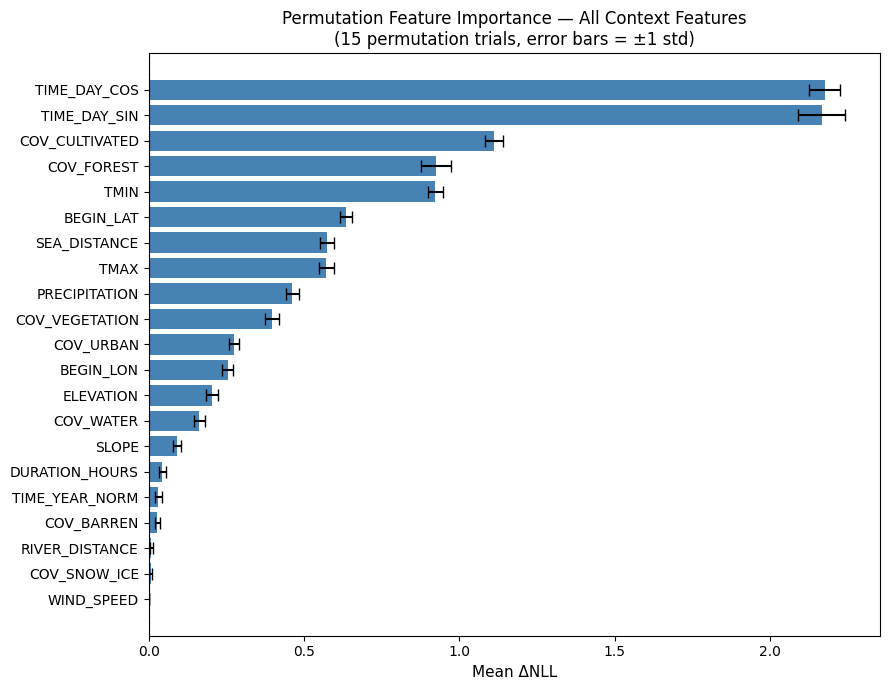

In [ ]:
flood_means, flood_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

# Storm

In [ ]:
EVENT_GROUP = 'Storm'
RUN_PATH = Path(f"../runs/flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

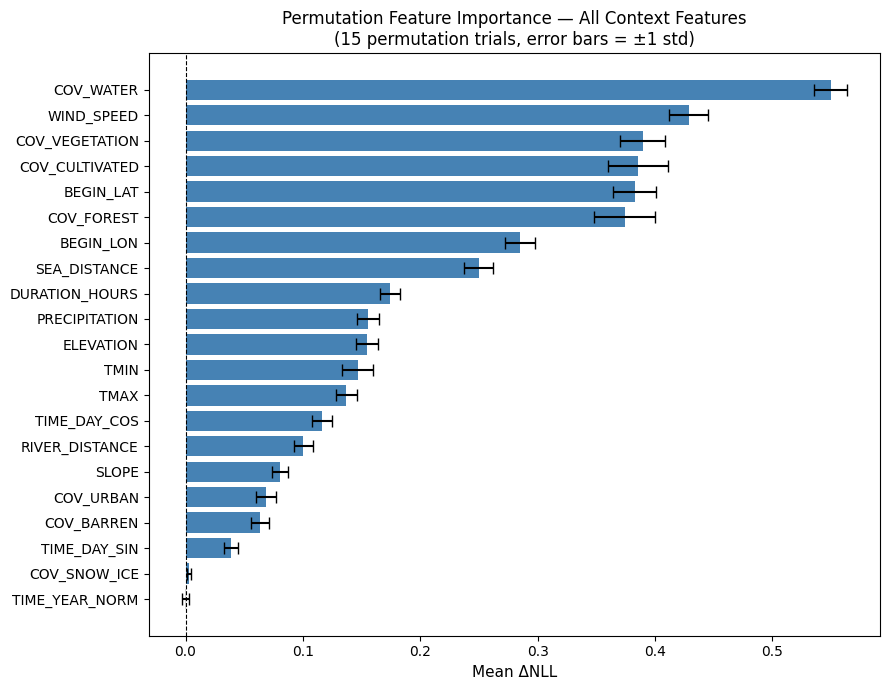

In [ ]:
storm_means, storm_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

# Drought

In [ ]:
EVENT_GROUP = 'Drought'
RUN_PATH = Path(f"../runs/flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

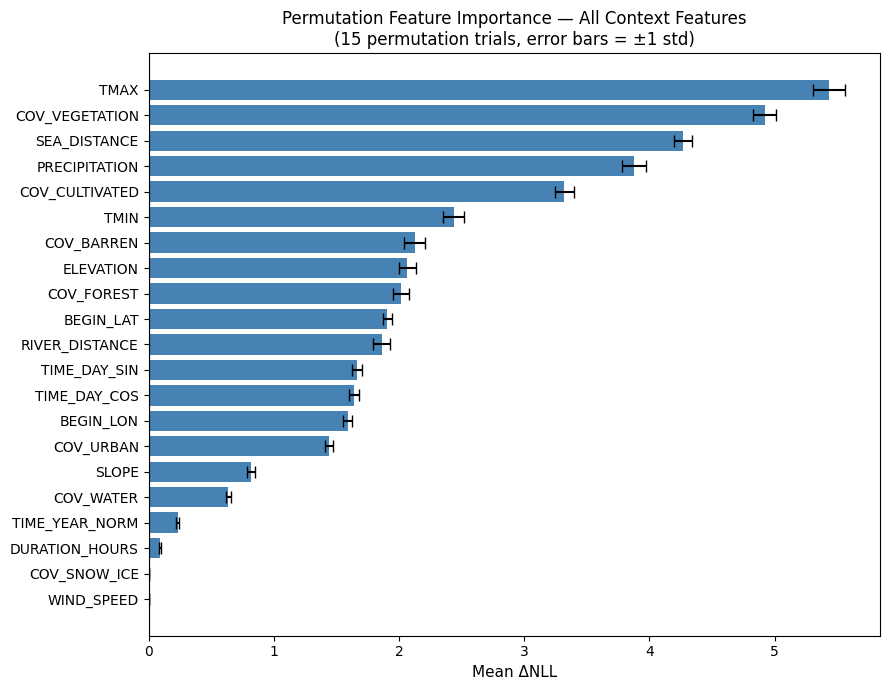

In [ ]:
drought_means, drought_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

# Wildfire

Model moved to cuda


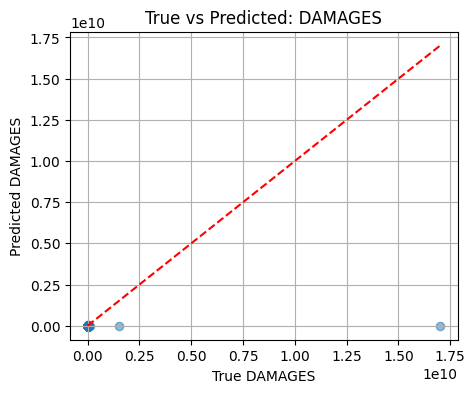

In [17]:
EVENT_GROUP = 'Wildfire'
RUN_PATH = Path(f"../runs/flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

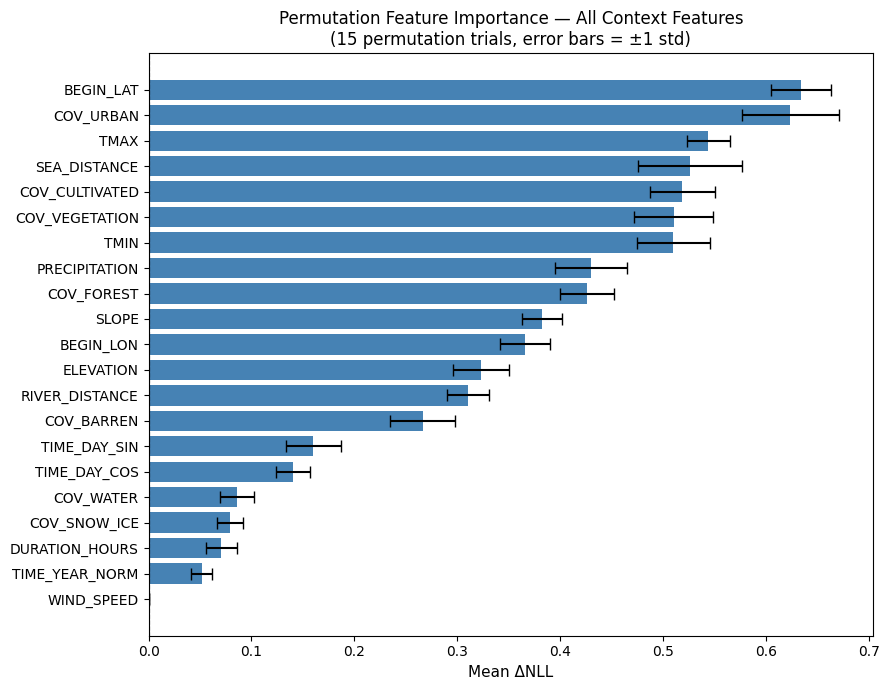

In [ ]:
wildfire_means, wildfire_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

# Avalanche

In [ ]:
EVENT_GROUP = 'Avalanche'
RUN_PATH = Path(f"../runs/flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

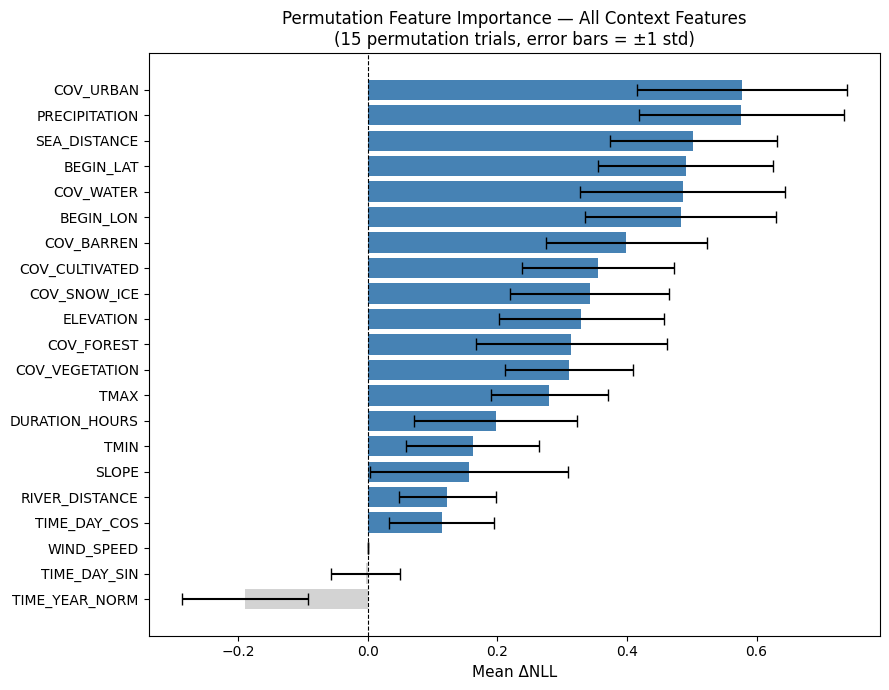

In [ ]:
avalanche_means, avalanche_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

# Freeze

In [ ]:
EVENT_GROUP = 'Freeze'
RUN_PATH = Path(f"../runs/flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

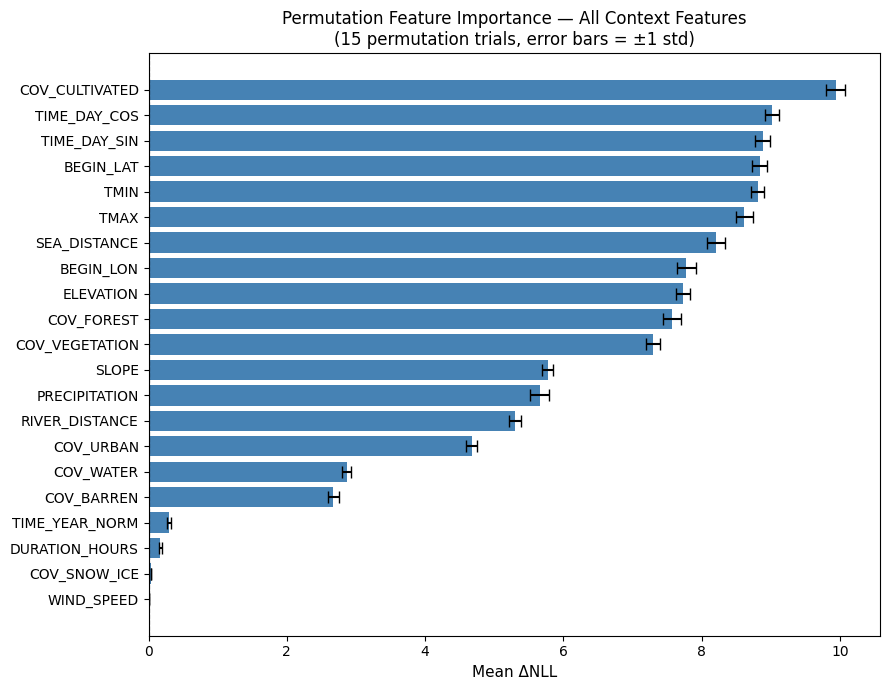

In [ ]:
freeze_means, freeze_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

# Heat

In [ ]:
EVENT_GROUP = 'Heat'
RUN_PATH = Path(f"../runs/flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

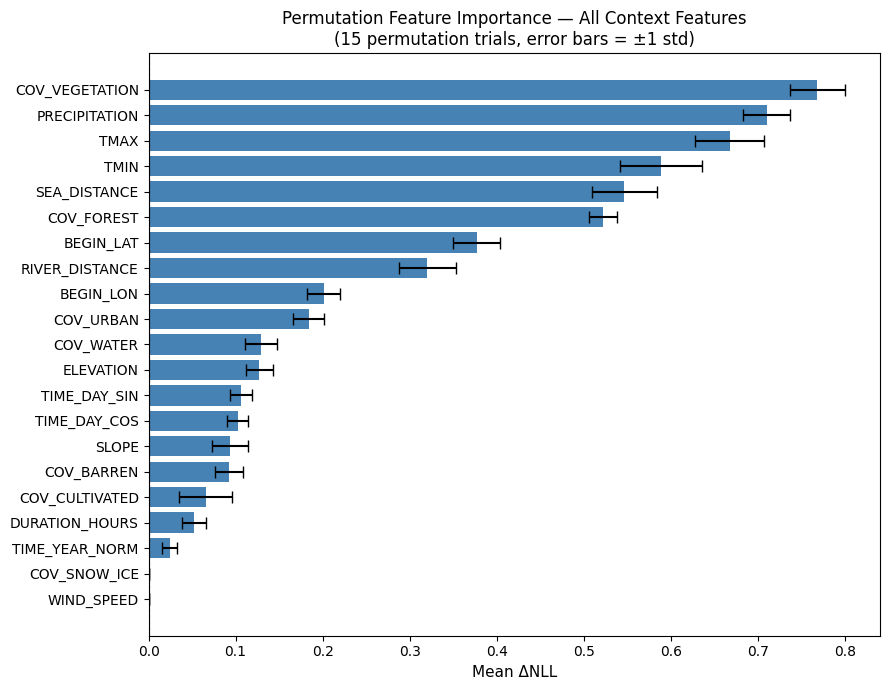

In [ ]:
heat_means, heat_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)